## 4. Επεξεργασία Δεδομένων

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Στο προηγούμενο κεφάλαιο είδαμε πώς τα γλωσσικά δεδομένα οργανώνονται σε πίνακες και πώς το DataFrame λειτουργεί ως βασική αναπαράσταση ενός dataset. Σε αυτό το κεφάλαιο περνάμε από τη δομή στη δράση: πώς επιλέγουμε, φιλτράρουμε, μετασχηματίζουμε και συνδυάζουμε δεδομένα, ώστε να τα προετοιμάσουμε για ανάλυση και μοντελοποίηση.


#### 4.1

In [ ]:
import pandas as pd

data = {
    "doc_id": [1, 2, 3, 4, 5],
    "text": [
        "Ὁ βασιλεὺς ἐχάρισεν γῆν τῷ μοναστηρίῳ.",
        "Διὰ τοῦτο ἐγένετο ἡ συμφωνία.",
        "Ἐγράφη ἐν μηνὶ Μαρτίῳ.",
        "",
        "Ὁ μάρτυς παρῆν καὶ ἐβεβαίωσεν."
    ],
    "century": [11, 12, 12, 11, 13],
    "label": ["grant", "agreement", None, "date", "witness"]
}

df = pd.DataFrame(data)
df.sample()

,doc_id,text,century,label
3,4,,11,date


In [ ]:
# column selection
df[["text", "label"]]

,text,label
0,Ὁ βασιλεὺς ἐχάρισεν γῆν τῷ μοναστηρίῳ.,grant
1,Διὰ τοῦτο ἐγένετο ἡ συμφωνία.,agreement
2,Ἐγράφη ἐν μηνὶ Μαρτίῳ.,None
3,,date
4,Ὁ μάρτυς παρῆν καὶ ἐβεβαίωσεν.,witness


In [ ]:
# row selection
df[df["century"] == 12]

,doc_id,text,century,label
1,2,Διὰ τοῦτο ἐγένετο ἡ συμφωνία.,12,agreement
2,3,Ἐγράφη ἐν μηνὶ Μαρτίῳ.,12,None


In [ ]:
# filtering based on quality conditions
df["text_length"] = df["text"].str.len()
df_non_empty = df[df["text_length"] > 0]
df_non_empty

,doc_id,text,century,label,text_length
0,1,Ὁ βασιλεὺς ἐχάρισεν γῆν τῷ μοναστηρίῳ.,11,grant,38
1,2,Διὰ τοῦτο ἐγένετο ἡ συμφωνία.,12,agreement,29
2,3,Ἐγράφη ἐν μηνὶ Μαρτίῳ.,12,None,22
4,5,Ὁ μάρτυς παρῆν καὶ ἐβεβαίωσεν.,13,witness,30


In [ ]:
# transformation and new columns
df["word_count"] = df["text"].str.split().str.len()
df["label_norm"] = df["label"].fillna("unknown")
df.sample(3)

,doc_id,text,century,label,text_length,word_count,label_norm
4,5,Ὁ μάρτυς παρῆν καὶ ἐβεβαίωσεν.,13,witness,30,5,witness
0,1,Ὁ βασιλεὺς ἐχάρισεν γῆν τῷ μοναστηρίῳ.,11,grant,38,6,grant
2,3,Ἐγράφη ἐν μηνὶ Μαρτίῳ.,12,None,22,4,unknown


#### 4.2

In [ ]:
df.isna()

,doc_id,text,century,label,text_length,word_count,label_norm
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
doc_id,0
text,0
century,0
label,1
text_length,0
word_count,0
label_norm,0


In [ ]:
df_no_missing_text = df[df["text"].str.len() > 0]

In [ ]:
df["label_filled"] = df["label"].fillna("unknown")

In [ ]:
df["word_count_filled"] = df["word_count"].fillna(df["word_count"].median())

In [ ]:
df

,doc_id,text,century,label,text_length,word_count,label_norm,label_filled,word_count_filled
0,1,Ὁ βασιλεὺς ἐχάρισεν γῆν τῷ μοναστηρίῳ.,11,grant,38,6,grant,grant,6
1,2,Διὰ τοῦτο ἐγένετο ἡ συμφωνία.,12,agreement,29,5,agreement,agreement,5
2,3,Ἐγράφη ἐν μηνὶ Μαρτίῳ.,12,None,22,4,unknown,unknown,4
3,4,,11,date,0,0,date,date,0
4,5,Ὁ μάρτυς παρῆν καὶ ἐβεβαίωσεν.,13,witness,30,5,witness,witness,5


#### 4.3

In [ ]:
df_extra = pd.DataFrame({
    "doc_id": [6, 7],
    "text": [
        "Ἐδόθη ἡ γῆ εἰς τὸν ναόν.",
        "Ὁ ἄρχων ἐμαρτύρησεν."
    ],
    "century": [12, 13],
    "label": ["grant", "witness"]
})

In [ ]:
df_all = pd.concat([df, df_extra], ignore_index=True)
df_all

,doc_id,text,century,label,text_length,word_count,label_norm,label_filled,word_count_filled
0,1,Ὁ βασιλεὺς ἐχάρισεν γῆν τῷ μοναστηρίῳ.,11,grant,38.0,6.0,grant,grant,6.0
1,2,Διὰ τοῦτο ἐγένετο ἡ συμφωνία.,12,agreement,29.0,5.0,agreement,agreement,5.0
2,3,Ἐγράφη ἐν μηνὶ Μαρτίῳ.,12,None,22.0,4.0,unknown,unknown,4.0
3,4,,11,date,0.0,0.0,date,date,0.0
4,5,Ὁ μάρτυς παρῆν καὶ ἐβεβαίωσεν.,13,witness,30.0,5.0,witness,witness,5.0
5,6,Ἐδόθη ἡ γῆ εἰς τὸν ναόν.,12,grant,NaN,NaN,NaN,NaN,NaN
6,7,Ὁ ἄρχων ἐμαρτύρησεν.,13,witness,NaN,NaN,NaN,NaN,NaN


In [ ]:
annotations = pd.DataFrame({
    "doc_id": [1, 2, 3, 5],
    "annotator": ["A1", "A1", "A2", "A2"],
    "confidence": [0.9, 0.85, 0.7, 0.95]
})

In [ ]:
df_merged = df.merge(annotations, on="doc_id", how="left")
df_merged

,doc_id,text,century,label,text_length,word_count,label_norm,label_filled,word_count_filled,annotator,confidence
0,1,Ὁ βασιλεὺς ἐχάρισεν γῆν τῷ μοναστηρίῳ.,11,grant,38,6,grant,grant,6,A1,0.90
1,2,Διὰ τοῦτο ἐγένετο ἡ συμφωνία.,12,agreement,29,5,agreement,agreement,5,A1,0.85
2,3,Ἐγράφη ἐν μηνὶ Μαρτίῳ.,12,None,22,4,unknown,unknown,4,A2,0.70
3,4,,11,date,0,0,date,date,0,NaN,NaN
4,5,Ὁ μάρτυς παρῆν καὶ ἐβεβαίωσεν.,13,witness,30,5,witness,witness,5,A2,0.95


In [ ]:
# size per century
df.groupby("century").size()

,0
century,
11,2
12,2
13,1


In [ ]:
# average word count by label
df.groupby("label")["word_count"].mean()

,word_count
label,
agreement,5.0
date,0.0
grant,6.0
witness,5.0


In [ ]:
# multiple groupings
df.groupby(["century", "label"]).size()

century  label    
11       date         1
         grant        1
12       agreement    1
13       witness      1
dtype: int64

#### 4.4

In [ ]:
# long format
annotations = pd.DataFrame({
    "doc_id": [1, 1, 2, 2, 5, 5],
    "annotator": ["A1", "A2", "A1", "A2", "A1", "A2"],
    "label": ["grant", "grant", "agreement", "agreement", "witness", "witness"]
})

In [ ]:
# pivoting
pivot_labels = annotations.pivot(
    index="doc_id",
    columns="annotator",
    values="label"
)
pivot_labels

annotator,A1,A2
doc_id,,
1,grant,grant
2,agreement,agreement
5,witness,witness


In [ ]:
# stacking
stacked = pivot_labels.stack()
stacked

doc_id  annotator
1       A1               grant
        A2               grant
2       A1           agreement
        A2           agreement
5       A1             witness
        A2             witness
dtype: object

In [ ]:
# multi-indexing
grouped = df.groupby(["century", "label"]).size()
grouped

century  label    
11       date         1
         grant        1
12       agreement    1
13       witness      1
dtype: int64

In [ ]:
grouped_df = grouped.reset_index(name="count")
grouped_df

,century,label,count
0,11,date,1
1,11,grant,1
2,12,agreement,1
3,13,witness,1


#### Legal Use Case

In [ ]:
from datasets import load_dataset
import pandas as pd

subsets = {}
for subset in ["subject", "chapter", "volume"]:
    subsets[subset] = pd.DataFrame(load_dataset("AI-team-UoA/greek_legal_code", subset)['train'])

df_subject = subsets["subject"].rename(columns={"label": "subject"})
df_chapter = subsets["chapter"].rename(columns={"label": "chapter"})
df_volume = subsets["volume"].rename(columns={"label": "volume"})

In [ ]:
merged_df = pd.merge(df_subject, df_chapter, on='text')
merged_df = pd.merge(merged_df, df_volume, on='text')
merged_df = merged_df[['text', 'subject', 'chapter', 'volume']]
merged_df.head()

,text,subject,chapter,volume
0,5. ΑΝΑΓΚ. ΝΟΜΟΣ 1204 της 20/29 Απρ. 1938 Περί...,1405,239,41
1,15. ΝΟΜΟΘΕΤ.ΔΙΑΤΑΓΜΑ υπ’ αριθ.262 της 8/8 Ιουλ...,555,183,35
2,29. ΝΟΜΟΘΕΤ. ΔΙΑΤΑΓΜΑ υπ’ αριθ. 1164 της 4 Μαρ...,932,203,6
3,29. ΠΡΟΕΔΡΙΚΟ ΔΙΑΤΑΓΜΑ υπ’ αριθ. 384 της 16/25...,912,332,4
4,6. ΝΟΜΟΣ υπ’ αριθ. 213 της 13/20 Νοεμ. 1975 (Φ...,1836,110,43


In [ ]:
hier_df = merged_df.set_index(["volume", "chapter", "subject"])
hier_df.head()

,,,text,text_length
volume,chapter,subject,,
41,239,1405,5. ΑΝΑΓΚ. ΝΟΜΟΣ 1204 της 20/29 Απρ. 1938 Περί...,6785
35,183,555,15. ΝΟΜΟΘΕΤ.ΔΙΑΤΑΓΜΑ υπ’ αριθ.262 της 8/8 Ιουλ...,895
6,203,932,29. ΝΟΜΟΘΕΤ. ΔΙΑΤΑΓΜΑ υπ’ αριθ. 1164 της 4 Μαρ...,198
4,332,912,29. ΠΡΟΕΔΡΙΚΟ ΔΙΑΤΑΓΜΑ υπ’ αριθ. 384 της 16/25...,2644
43,110,1836,6. ΝΟΜΟΣ υπ’ αριθ. 213 της 13/20 Νοεμ. 1975 (Φ...,68194


In [ ]:
hier_df.loc[1]

text  \
chapter subject                                                      
142     864      282. ΠΡΟΕΔΡΙΚΟ ΔΙΑΤΑΓΜΑ υπ΄ αριθ. 187 της 21-3...   
        864      196. ΠΡΟΕΔΡΙΚΟ ΔΙΑΤΑΓΜΑ υπ’ αριθ. 31 της 15/21...   
        1243     27. ΒΑΣΙΛΙΚΟΝ ΔΙΑΤΑΓΜΑ της 16 Δεκ. 1953/16 Ιαν...   
        1052     104. ΑΠΟΦΑΣΗ ΥΠΟΥΡΓΩΝ ΕΘΝΙΚΗΣ ΟΙΚΟΝΟΜΙΑΣ ΚΑΙ Ο...   
148     725      53. ΑΠΟΦΑΣΗ ΥΠΟΥΡΓΟΥ ΓΕΩΡΓΙΑΣ Αριθ. 40189 της ...   
...                                                            ...   
365     1899     26. ΝΟΜΟΣ 4122 της 22/28 Μαρτ. 1929 Περί κυρώσ...   
280     32       52. ΑΠΟΦΑΣΗ ΥΠΟΥΡΓΩΝ ΟΙΚΟΝΟΜΙΚΩΝ ΚΑΙ ΓΕΩΡΓΙΑΣ ...   
42      1698     33. ΠΡΟΕΔΡΙΚΟΝ ΔΙΑΤΑΓΜΑ υπ’ αριθ. 906 της 26 Σ...   
142     1052     67. ΑΠΟΦΑΣΗ ΥΠΟΥΡΓΩΝ ΕΘΝΙΚΗΣ ΟΙΚΟΝΟΜΙΑΣ, ΟΙΚΟΝ...   
148     725      41. ΑΠΟΦΑΣΗ ΑΝΑΠΛΗΡΩΤΗ ΥΠΟΥΡΓΟΥ ΕΘΝΙΚΗΣ ΟΙΚΟΝΟ...   

                 text_length  
chapter subject               
142     864            18819  
        864              138  
        1243            1063  
        1052             375  
148     725              336  
...                      ...  
365     1899             197  
280     32               266  
42      1698            2426  
142     1052             180  
148     725              389  

[1168 rows x 2 columns]

In [ ]:
hier_df = hier_df.sort_index()
hier_df.loc[(1, 142)]

,text,text_length
subject,,
864,282. ΠΡΟΕΔΡΙΚΟ ΔΙΑΤΑΓΜΑ υπ΄ αριθ. 187 της 21-3...,18819
864,196. ΠΡΟΕΔΡΙΚΟ ΔΙΑΤΑΓΜΑ υπ’ αριθ. 31 της 15/21...,138
864,13. ΝΟΜΟΣ 4405 της 20/27 Αυγ. 1929 Περί συμπλη...,5740
864,254. ΠΡΟΕΔΡΙΚΟ ΔΙΑΤΑΓΜΑ υπ’ αριθ. 94 της 22/22...,26719
864,310. ΑΠΟΦΑΣΗ ΥΠΟΥΡΓΟΥ ΓΕΩΡΓΙΑΣ Αριθ. 261112 τη...,453
...,...,...
1399,24. ΑΠΟΦΑΣΙΣ ΥΠΟΥΡΓΟΥ ΓΕΩΡΓΙΑΣ Αριθ. 57929/222...,173
1399,16. ΒΑΣΙΛΙΚΟΝ ΔΙΑΤΑΓΜΑ υπ’ αριθ. 192 της 9/18 ...,26649
1399,21. ΑΠΟΦΑΣΙΣ ΥΠΟΥΡΓΟΥ ΓΕΩΡΓΙΑΣ Αριθ. 47147/179...,22594


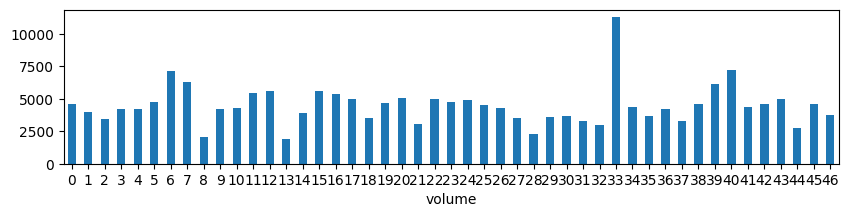

In [ ]:
hier_df.groupby(level="volume")["text_length"].mean().plot.bar(figsize=(10,2), rot=0);

In [ ]:
hier_df.groupby(level=["volume", "chapter"])["text_length"].describe()

count          mean           std      min       25%      50%  \
volume chapter                                                                  
0      14       103.0   4495.242718   7514.646978    142.0    422.50   1229.0   
       69         1.0  24917.000000           NaN  24917.0  24917.00  24917.0   
       116       21.0   2218.761905   3291.985372    111.0    220.00    404.0   
       156      135.0   3802.074074  12063.948034    115.0    237.50    521.0   
       167      133.0   4072.766917  17287.809707    121.0    267.00    529.0   
...               ...           ...           ...      ...       ...      ...   
46     166      169.0   6362.775148  30550.366637     85.0    252.00    504.0   
       191       78.0   7500.410256  19381.163043     41.0    203.75    752.0   
       200        8.0    355.625000    294.440844    114.0    212.75    256.5   
       325       56.0    440.267857   1590.006844     62.0    116.00    146.5   
       328        6.0    292.000000    175.658760     98.0    138.00    289.0   

                     75%       max  
volume chapter                      
0      14        4405.50   46232.0  
       69       24917.00   24917.0  
       116       2542.00   13208.0  
       156       2246.00  102585.0  
       167       1809.00  188971.0  
...                  ...       ...  
46     166       2118.00  269387.0  
       191       4268.50  137845.0  
       200        355.50    1045.0  
       325        255.50   12000.0  
       328        431.75     509.0  

[389 rows x 8 columns]

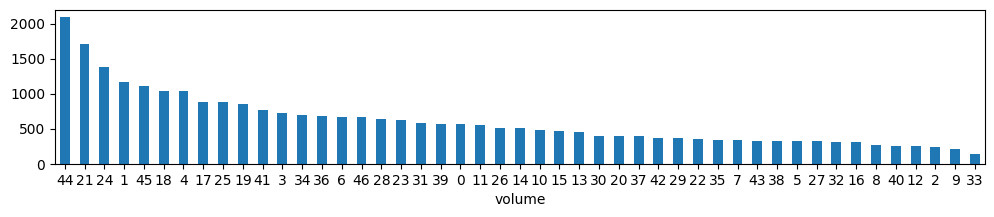

In [ ]:
vol_balance = merged_df["volume"].value_counts()
vol_balance.plot.bar(figsize=(12,2), rot=0);

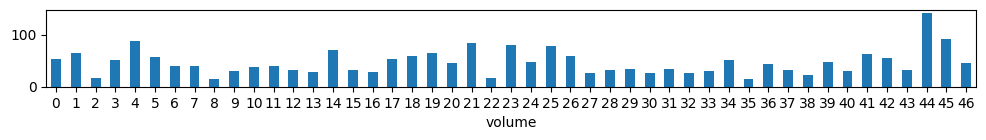

In [ ]:
vol_variety = merged_df.groupby("volume")["subject"].nunique()
vol_variety.plot.bar(figsize=(12,1), rot=0);

In [ ]:
merged_df["subject"].value_counts().head(5)

,count
subject,
331,793
988,377
1496,186
1019,186
864,148


In [ ]:
merged_df.groupby("chapter")["subject"].nunique().sort_values(ascending=False)

,subject
chapter,
331,52
112,23
242,22
197,21
25,20
...,...
69,1
353,1
348,1


In [ ]:
volume_subject_table = merged_df.pivot_table(
    index="volume",
    columns="subject",
    aggfunc="size",
    fill_value=0
)
volume_subject_table

subject,0,1,2,3,4,5,6,7,8,9,...,2275,2276,2277,2278,2279,2280,2281,2282,2283,2284
volume,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,13,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,30,0,1,0,0,0,0,0,0,0,...,5,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,11,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
merged_df["text_length"] = merged_df["text"].str.len()
merged_df.groupby("volume")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
volume,,,,,,,,
0,561.0,4586.317291,14427.456453,111.0,301.00,945.0,3163.00,193785.0
1,1168.0,4025.101027,14980.913008,53.0,245.00,529.0,2391.00,296802.0
2,236.0,3467.656780,9147.912744,112.0,246.75,469.5,2149.75,78610.0
3,731.0,4226.827633,9620.709533,83.0,244.00,540.0,3276.00,68699.0
4,1038.0,4218.052023,18106.155673,59.0,254.25,604.0,2293.50,447114.0
5,325.0,4769.483077,16263.790600,32.0,240.00,615.0,2048.00,180088.0
6,673.0,7169.173848,31358.170711,56.0,235.00,467.0,2822.00,492252.0
7,332.0,6272.087349,23382.570701,72.0,270.25,729.0,4116.50,353590.0
8,274.0,2039.492701,4615.567136,91.0,288.25,641.5,2072.50,46375.0


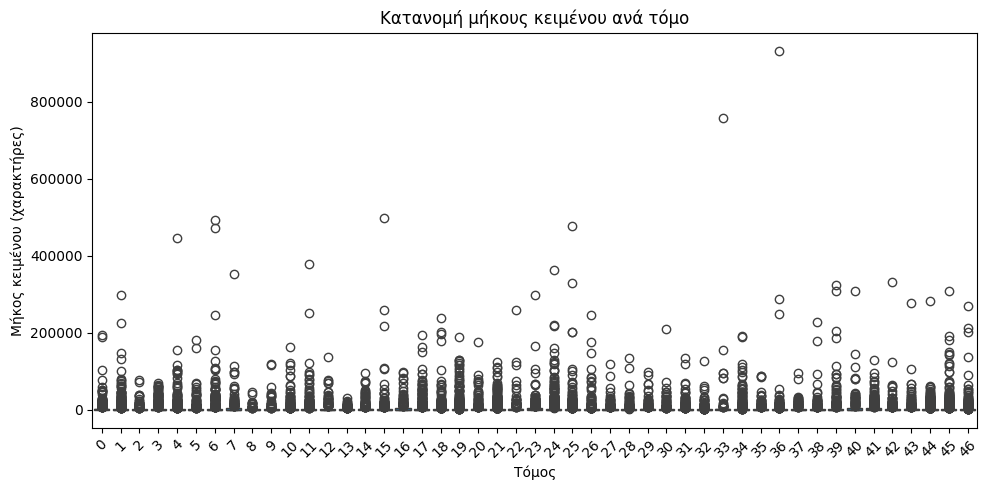

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=merged_df,
    x="volume",
    y="text_length"
)
plt.title("Κατανομή μήκους κειμένου ανά τόμο")
plt.xlabel("Τόμος")
plt.ylabel("Μήκος κειμένου (χαρακτήρες)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()